<a href="https://colab.research.google.com/github/Nkengfack/Bank_marketing_ml_Classifications/blob/main/bank_marketing_ML_performance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#A Comparative Performance Analysis of Machine Learning Models for Bank Term Deposit Subscription Prediction

##MSc Data Science Final Project, University of Hertfordshire, Module 7PAM2002.

Part 1 covers the data work behind Section 3 of the report: loading and
inspecting the UCI Bank Marketing dataset, finding the hidden missing values,
resolving the pdays anomaly, and exploring the distributions that shape the
modelling decisions in Part 2.

## 3.1 Libraries and display settings



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

# One colour per outcome, reused across every chart
COLOUR_NO  = '#378ADD'   # did not subscribe
COLOUR_YES = '#D85A30'   # subscribed
PALETTE    = [COLOUR_NO, COLOUR_YES]

# The UCI target column is renamed to this on loading
TARGET = 'subscribed'

## 3.2 Loading the data

The dataset is read straight from my GitHub repository.


In [2]:
URL = ('https://raw.githubusercontent.com/Nkengfack/'
       'Bank_marketing_ml_Classifications/refs/heads/main/'
       'bank_marketing_dataset.csv')

marketing = pd.read_csv(URL, sep=';')
marketing.rename(columns={'y': TARGET}, inplace=True)

assert marketing.shape == (41188, 21), 'Unexpected shape, check the source file'

print(f'Rows: {marketing.shape[0]:,}   Columns: {marketing.shape[1]}')
print(marketing.columns.tolist())

Rows: 41,188   Columns: 21
['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'subscribed']


## 3.3 First inspection

To see how the dataset looks like


In [3]:
marketing.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,subscribed
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no


In [4]:
display(marketing)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,subscribed
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,334,1,999,0,nonexistent,-1.10,94.77,-50.80,1.03,4963.60,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,383,1,999,0,nonexistent,-1.10,94.77,-50.80,1.03,4963.60,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,189,2,999,0,nonexistent,-1.10,94.77,-50.80,1.03,4963.60,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,442,1,999,0,nonexistent,-1.10,94.77,-50.80,1.03,4963.60,yes


In [5]:
marketing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

info() reports a full 41,188 non-null entries in every column. That looks
clean, but it is misleading, this dataset hides its missing values as text,
which Section 3.5 deals with.

## 3.4 Summary statistics



In [6]:

marketing.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00
mean,40.02,258.29,2.57,962.48,0.17,0.08,93.58,-40.50,3.62,5167.04
std,10.42,259.28,2.77,186.91,0.49,1.57,0.58,4.63,1.73,72.25
min,17.00,0.00,1.00,0.00,0.00,-3.40,92.20,-50.80,0.63,4963.60
25%,32.00,102.00,1.00,999.00,0.00,-1.80,93.08,-42.70,1.34,5099.10
50%,38.00,180.00,2.00,999.00,0.00,1.10,93.75,-41.80,4.86,5191.00
75%,47.00,319.00,3.00,999.00,0.00,1.40,93.99,-36.40,4.96,5228.10
max,98.00,4918.00,56.00,999.00,7.00,1.40,94.77,-26.90,5.04,5228.10


The numeric summary will be Table 3.1 in the report. Three things stand out.
The mean of pdays is 962 against a median of 999, which makes no sense as a
number of days and points to 999 being a placeholder rather than a measurement.
The maximum of campaign is 56 contacts against a 75th percentile of 3, a
heavy right tail. And duration spans from 0 seconds to over an hour, its
role is examined separately in Part 2

In [7]:
marketing.describe(include='object')

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,subscribed
count,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,10422,24928,12168,32588,21576,33950,26144,13769,8623,35563,36548


The categorical summary shows the most frequent value of each text column.
unknown appears as the top value nowhere, but it is present in several
columns, which motivates the next check.

## 3.5 Hidden missing values

There are no NaN values anywhere, yet several categorical columns use the
string unknown as a placeholder. It behaves exactly like a missing value
but is invisible to isnull(), so it has to be counted directly.

In [8]:
marketing.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


In [9]:
# Identify categorical columns, excluding the target variable
object_cols = marketing.select_dtypes(include='object').columns.drop(TARGET)

# Count occurrences of the 'unknown' placeholder in each column
unknown_counts = (
    marketing[object_cols]
    .apply(lambda col: (col == 'unknown').sum()) # Count matches for 'unknown'
    .loc[lambda s: s > 0]                        # Filter out columns with zero unknowns
    .sort_values(ascending=False)
)

# Construct a summary table with raw counts and percentages
unknown_table = pd.DataFrame({
    'Unknown count': unknown_counts,
    'Unknown (%)'  : (unknown_counts / len(marketing) * 100).round(2)
})

print(unknown_table.to_string())
print(f'\nTotal unknown entries: {unknown_counts.sum():,}')

           Unknown count  Unknown (%)
default             8597        20.87
education           1731         4.20
housing              990         2.40
loan                 990         2.40
job                  330         0.80
marital               80         0.19

Total unknown entries: 12,718


## 3.6 The pdays anomaly

pdays records the days since a client was last contacted in a previous
campaign, and previous records how many prior contacts there were. The UCI
documentation says pdays = 999 means the client was not previously
contacted. Cross checking the two columns tests whether that is actually
true.

In [10]:
never      = (marketing['previous'] == 0) & (marketing['pdays'] == 999)
no_date    = (marketing['previous'] >  0) & (marketing['pdays'] == 999)
date_known = (marketing['previous'] >  0) & (marketing['pdays'] != 999)

scenarios = pd.DataFrame(
    {'Clients': [never.sum(), no_date.sum(), date_known.sum()]},
    index=['previous = 0 and pdays = 999',
           'previous > 0 and pdays = 999',
           'previous > 0 and pdays < 999']
)

print(scenarios.to_string())

                              Clients
previous = 0 and pdays = 999    35563
previous > 0 and pdays = 999     4110
previous > 0 and pdays < 999     1515


## 3.7 Duplicate records

The dataset has no client identifier, so an exact duplicate row could in
principle be two different people with identical attributes. At 12 rows out
of 41,188 the effect either way is negligible, and the standard choice is
to remove exact duplicates so no record is counted twice in the
distributions below or in model training.

In [11]:
duplicates = marketing.duplicated().sum()
marketing.drop_duplicates(keep='first', ignore_index=True, inplace=True)

print(f'Duplicate rows removed: {duplicates}')
print(f'Rows remaining: {len(marketing):,}')

Duplicate rows removed: 12
Rows remaining: 41,176


## 3.8 Feature type classification

The columns are split into numeric and categorical lists once, and every
later cell reuses these lists. This is the same split the Part 2
ColumnTransformer applies, scaling for the numeric columns and one hot
encoding for the categorical ones.

In [12]:
num_features = marketing.select_dtypes(include='number').columns.tolist()
cat_features = [col for col in marketing.select_dtypes(include='object').columns
                if col != TARGET]

print(f'Numerical features  ({len(num_features)}): {num_features}')
print(f'Categorical features ({len(cat_features)}): {cat_features}')

Numerical features  (10): ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Categorical features (10): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


## 3.9 Class distribution

The split is 88.7% no against 11.3% yes. Predicting no for everyone scores
88.7% accuracy, so evaluation uses F1, PR AUC and MCC, and class weighting
enters the tuning grids in Part 2. This is Figure 3.1 in the report.

            Count  Percentage (%)
subscribed                       
no          36537           88.73
yes          4639           11.27


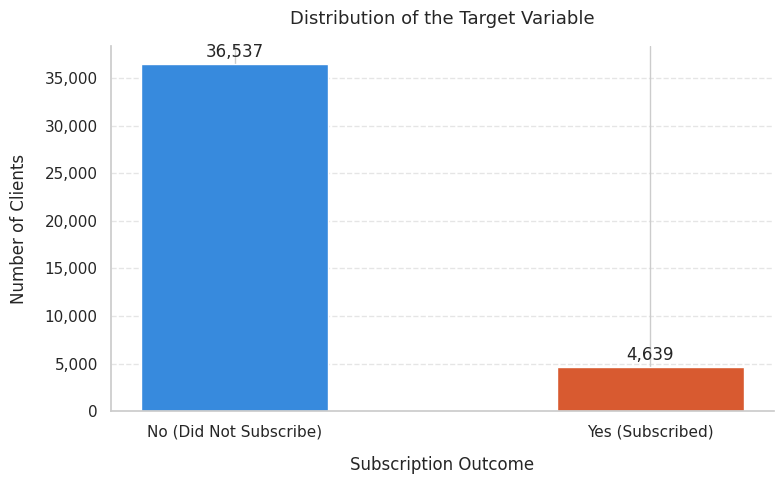

In [13]:
counts = marketing[TARGET].value_counts()
pcts   = marketing[TARGET].value_counts(normalize=True) * 100

print(pd.DataFrame({'Count': counts, 'Percentage (%)': pcts.round(2)}))

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    ['No (Did Not Subscribe)', 'Yes (Subscribed)'],
    counts.values,
    color=PALETTE,
    width=0.45,
    edgecolor='white'
)

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 280,
        f'{bar.get_height():,}',
        ha='center', va='bottom', fontsize=12
    )

plt.title('Distribution of the Target Variable', pad=16, fontsize=13)
plt.xlabel('Subscription Outcome', labelpad=12)
plt.ylabel('Number of Clients', labelpad=12)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
sns.despine(top=True, right=True)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('fig_3_1_class_distribution.png', dpi=300)
plt.show()

## 3.10 Distributions of the numerical features

duration, campaign and previous are heavily right skewed. pdays is one
spike at 999, confirming the flag conversion in Part 2. The economic
indicators hold one value per campaign period, so they describe when a
client was called, not who the client is.

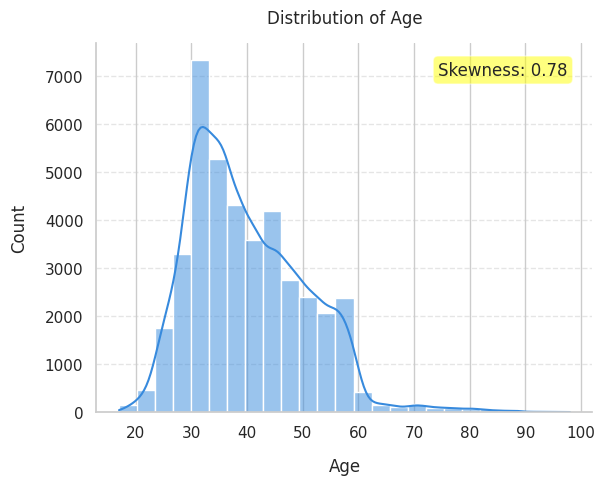

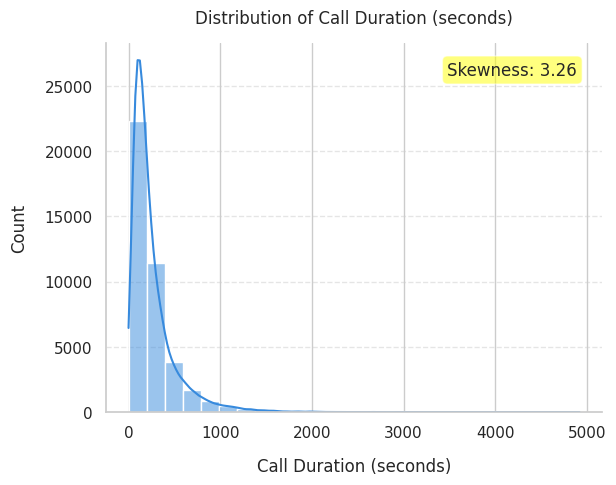

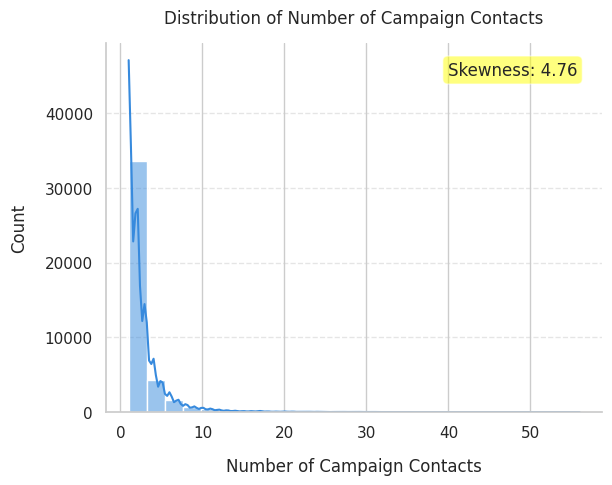

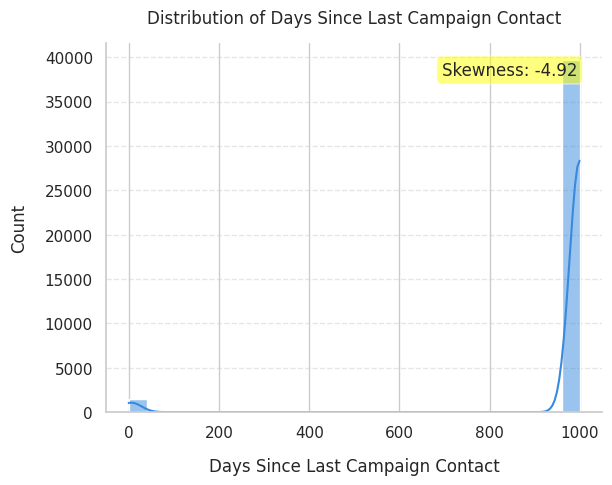

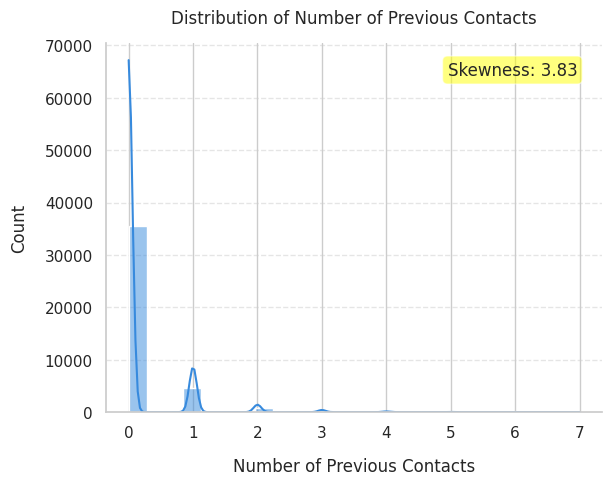

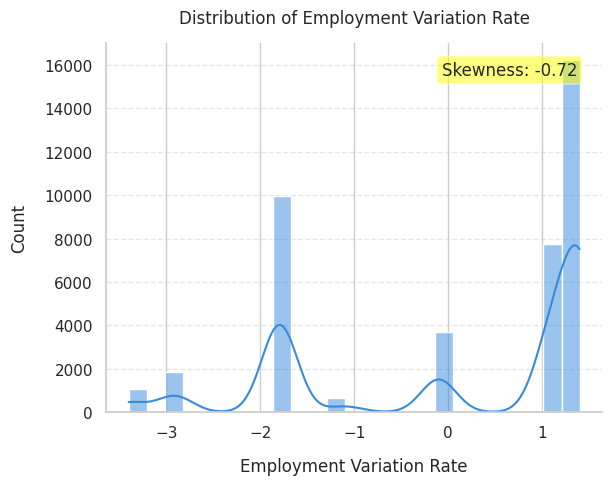

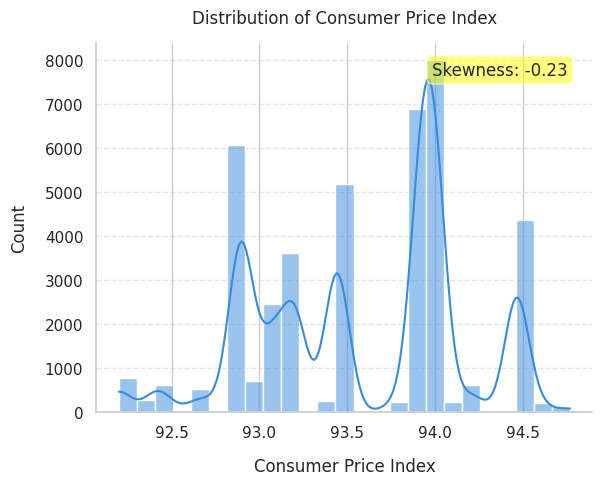

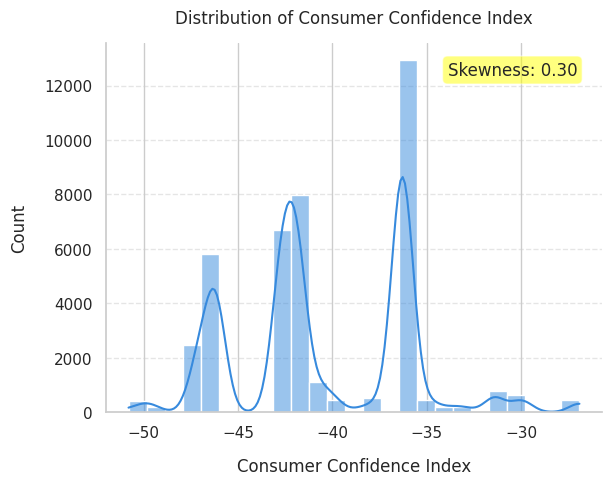

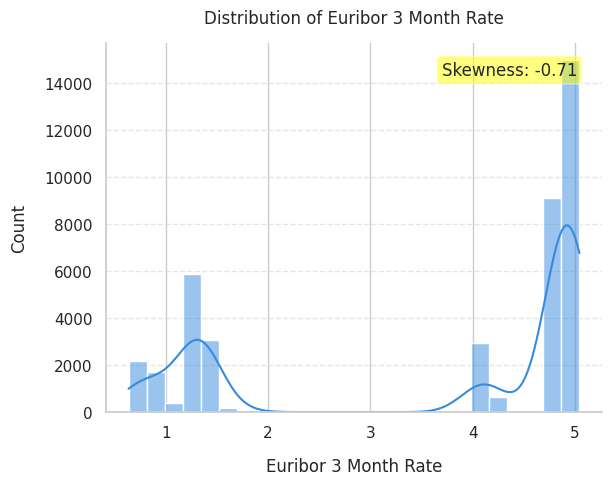

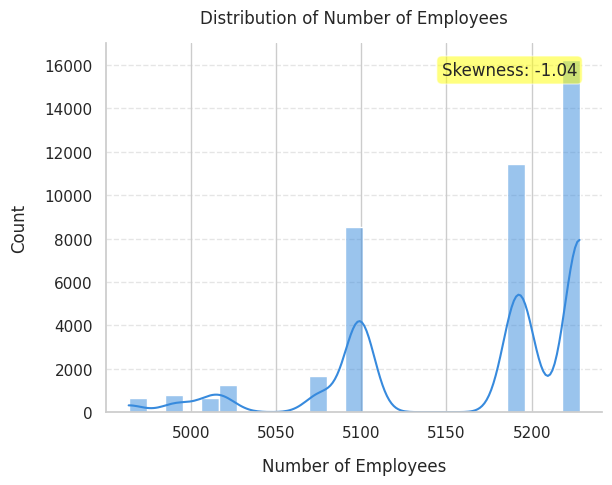

In [14]:
feature_names = {
    'age'            : 'Age',
    'duration'       : 'Call Duration (seconds)',
    'campaign'       : 'Number of Campaign Contacts',
    'pdays'          : 'Days Since Last Campaign Contact',
    'previous'       : 'Number of Previous Contacts',
    'emp.var.rate'   : 'Employment Variation Rate',
    'cons.price.idx' : 'Consumer Price Index',
    'cons.conf.idx'  : 'Consumer Confidence Index',
    'euribor3m'      : 'Euribor 3 Month Rate',
    'nr.employed'    : 'Number of Employees'
}

for col in num_features:
    fig, ax = plt.subplots()
    sns.histplot(marketing[col], kde=True, bins=25, color=COLOUR_NO)
    plt.title(f'Distribution of {feature_names.get(col, col)}', pad=14)
    plt.text(
        0.95, 0.95, f'Skewness: {marketing[col].skew():.2f}',
        transform=ax.transAxes, ha='right', va='top',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.5)
    )
    plt.xlabel(feature_names.get(col, col), labelpad=12)
    plt.ylabel('Count', labelpad=12)
    sns.despine(top=True, right=True)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.savefig(f'dist_{col.replace(".", "_")}.png', dpi=300)
    plt.show()
    print('\n')

## 3.11 Distributions of the categorical features

admin. is the largest job group and university degree the largest education
level. May holds around a third of all contacts, December almost none.
default is binary in practice, a handful of yes values, everyone else no
or unknown.

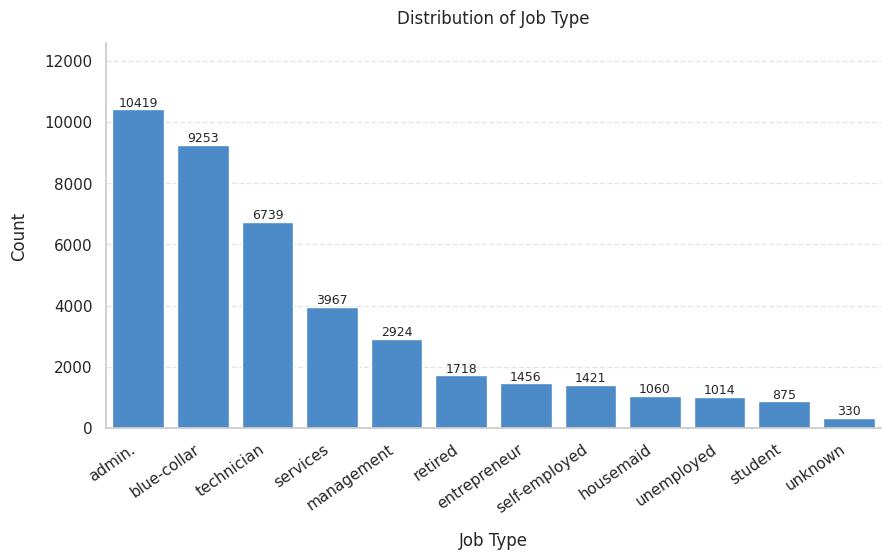

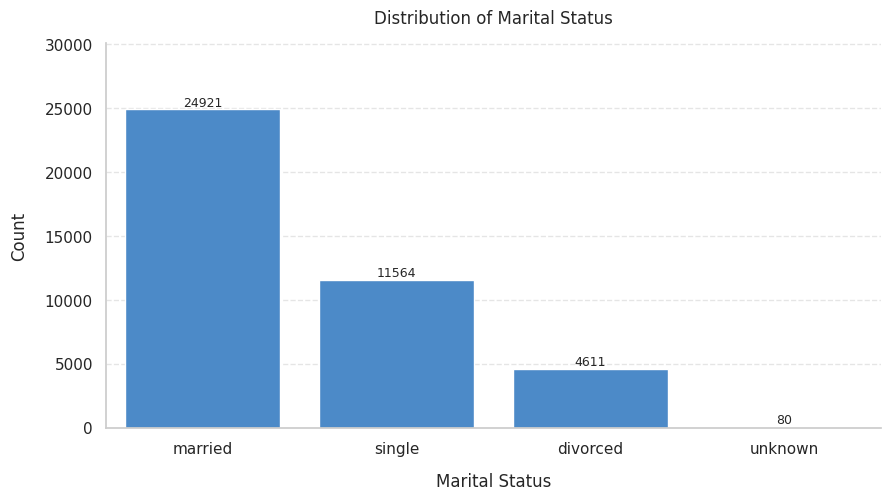

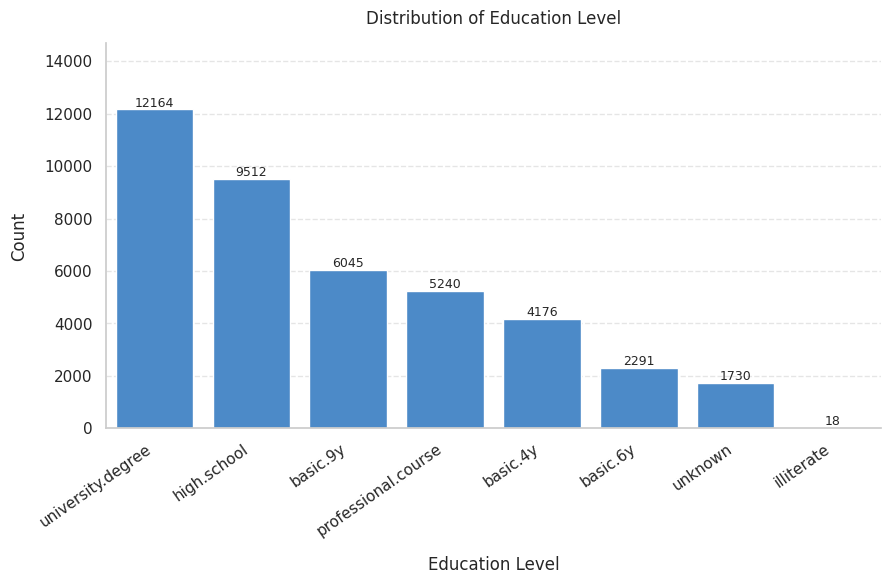

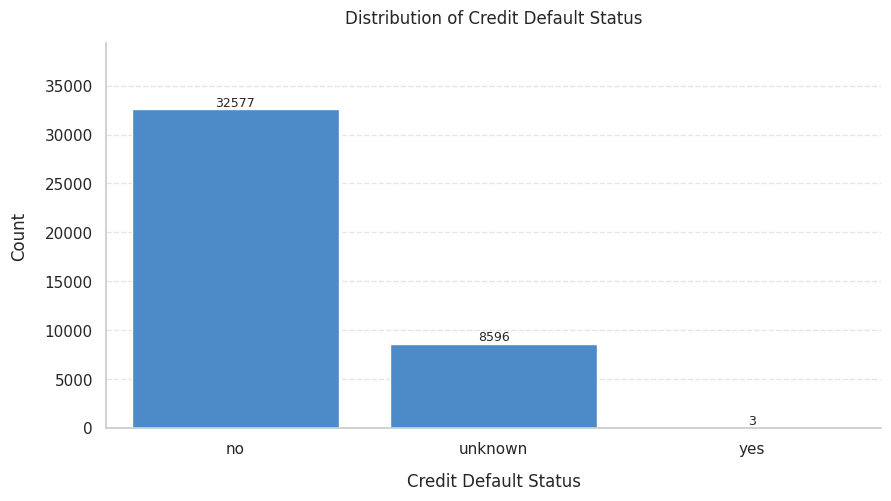

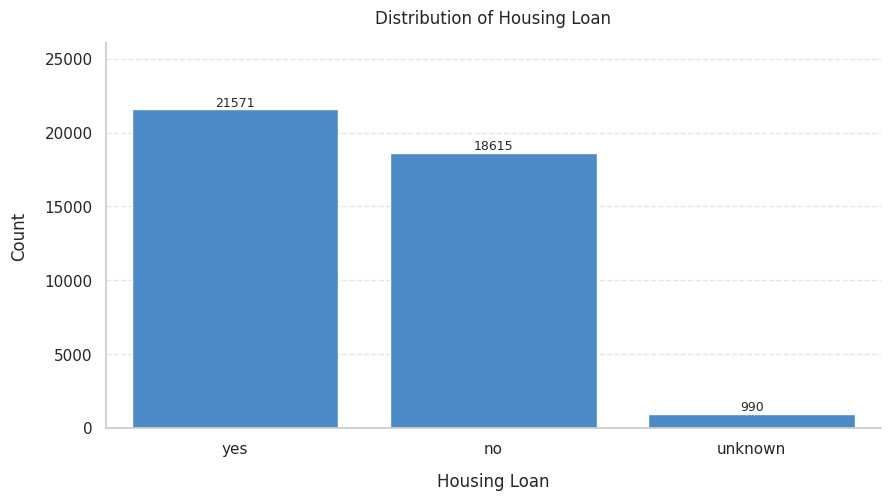

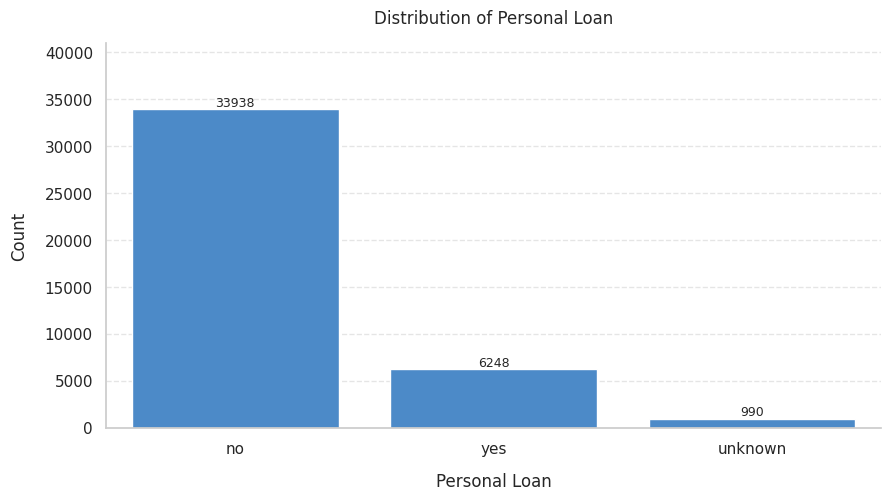

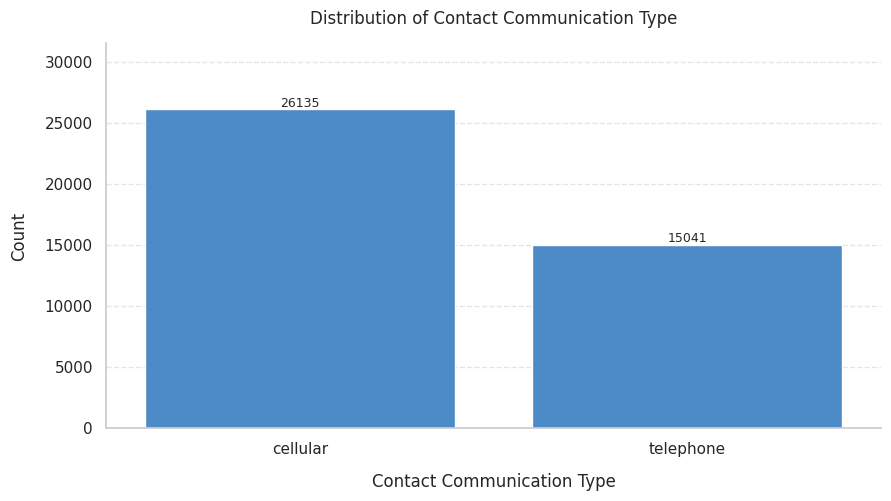

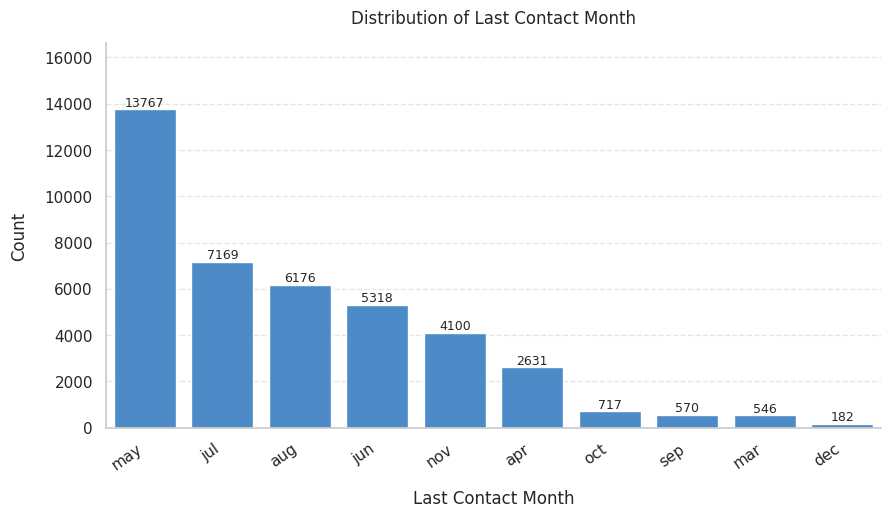

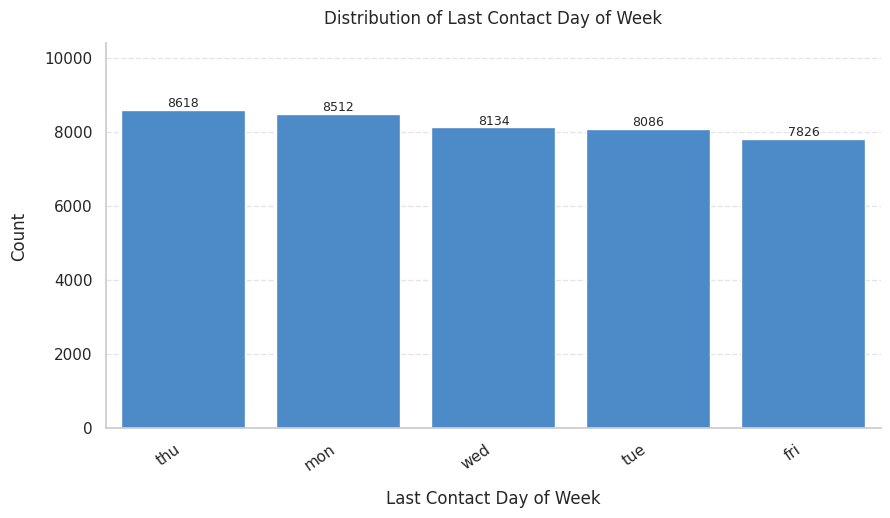

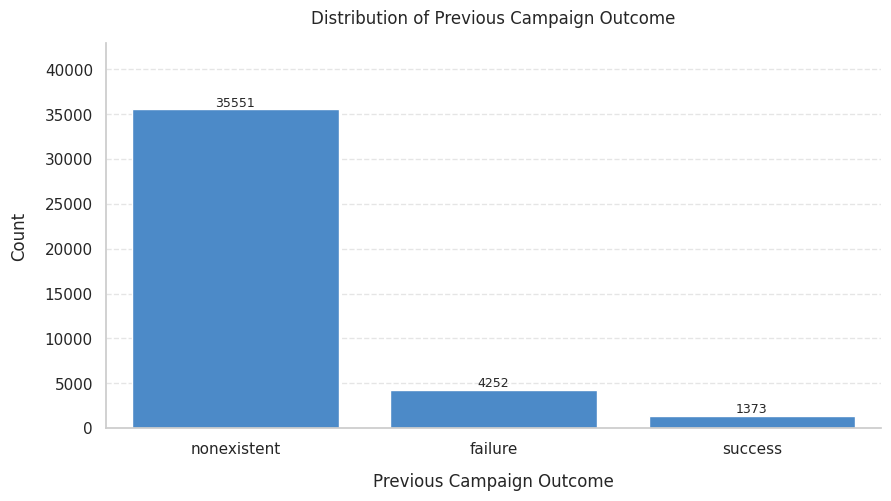

In [15]:
cat_feature_names = {
    'job'         : 'Job Type',
    'marital'     : 'Marital Status',
    'education'   : 'Education Level',
    'default'     : 'Credit Default Status',
    'housing'     : 'Housing Loan',
    'loan'        : 'Personal Loan',
    'contact'     : 'Contact Communication Type',
    'month'       : 'Last Contact Month',
    'day_of_week' : 'Last Contact Day of Week',
    'poutcome'    : 'Previous Campaign Outcome'
}

for col in cat_features:
    fig, ax = plt.subplots(figsize=(10, 5))
    order = marketing[col].value_counts().index
    sns.countplot(data=marketing, x=col, order=order, color=COLOUR_NO, ax=ax)

    if marketing[col].nunique() > 4:
        plt.xticks(rotation=35, ha='right')

    for container in ax.containers:
        ax.bar_label(container, fmt='%d', label_type='edge', fontsize=9)

    plt.title(f'Distribution of {cat_feature_names.get(col, col)}', pad=14)
    plt.xlabel(cat_feature_names.get(col, col), labelpad=12)
    plt.ylabel('Count', labelpad=12)
    plt.ylim(0, ax.get_ylim()[1] * 1.15)
    sns.despine(top=True, right=True)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.savefig(f'count_{col.replace(".", "_")}.png', dpi=300)
    plt.show()
    print('\n')

## 3.12 Subscription rate by category

Where the bank called and where calls worked disagree. Prior campaign
success converts at around 65%, the strongest single signal. Students and
retired clients lead the job rates, blue collar sits last. Cellular
converts at roughly three times landline. May has the most calls and one
of the worst rates. day_of_week is excluded, its rates are flat.

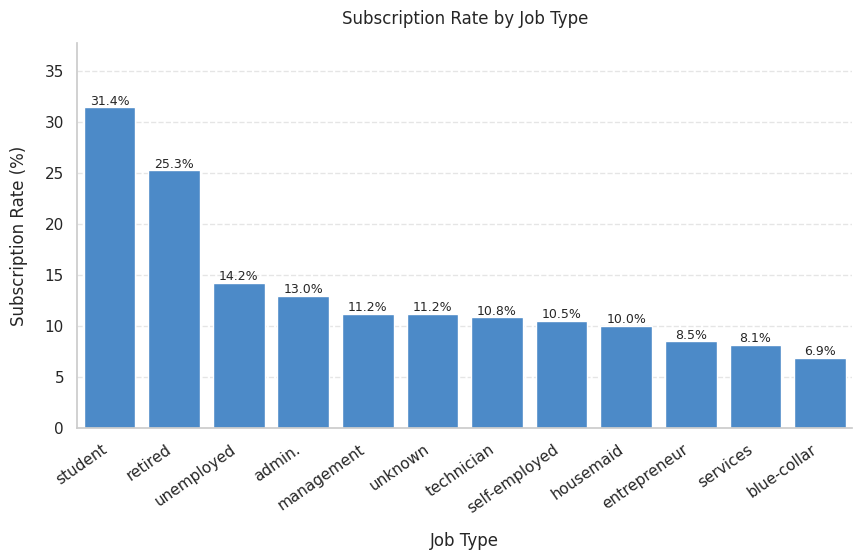

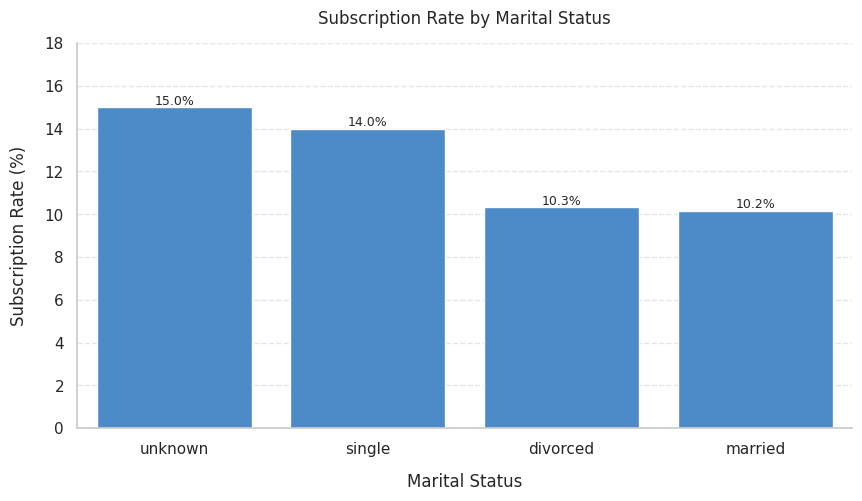

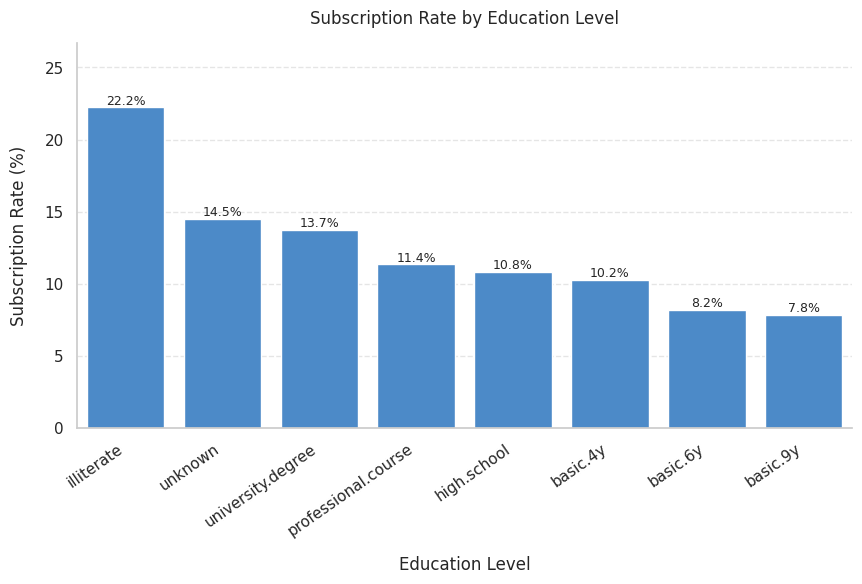

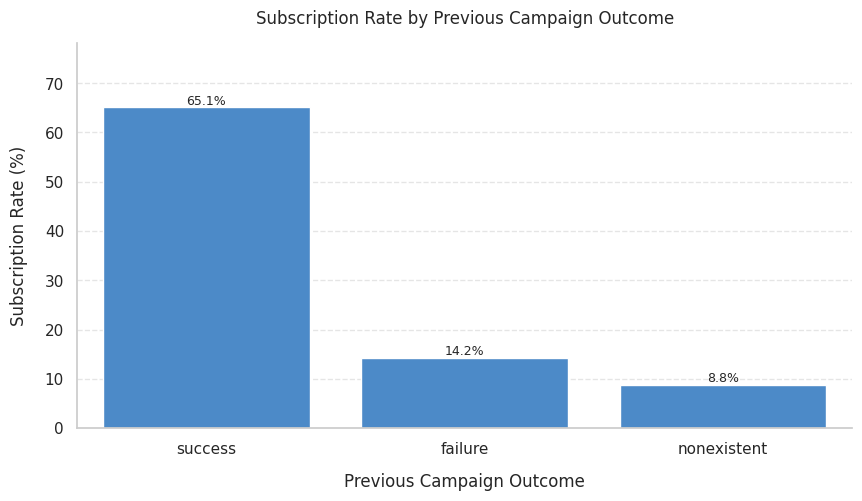

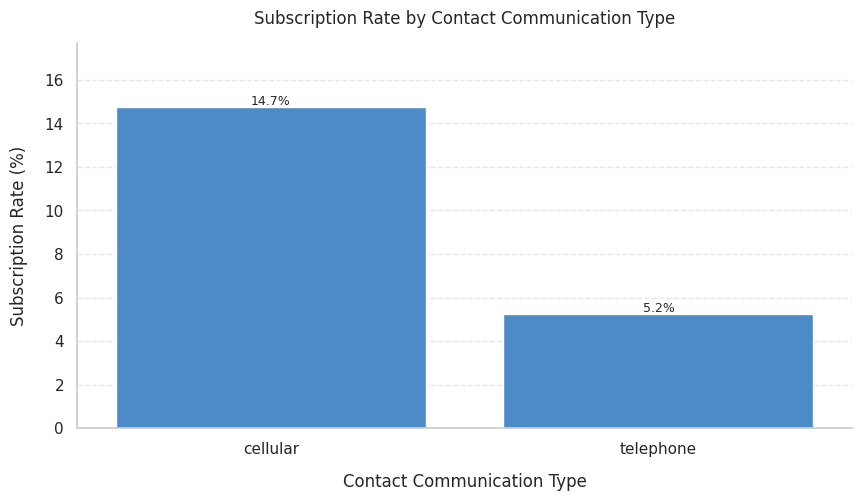

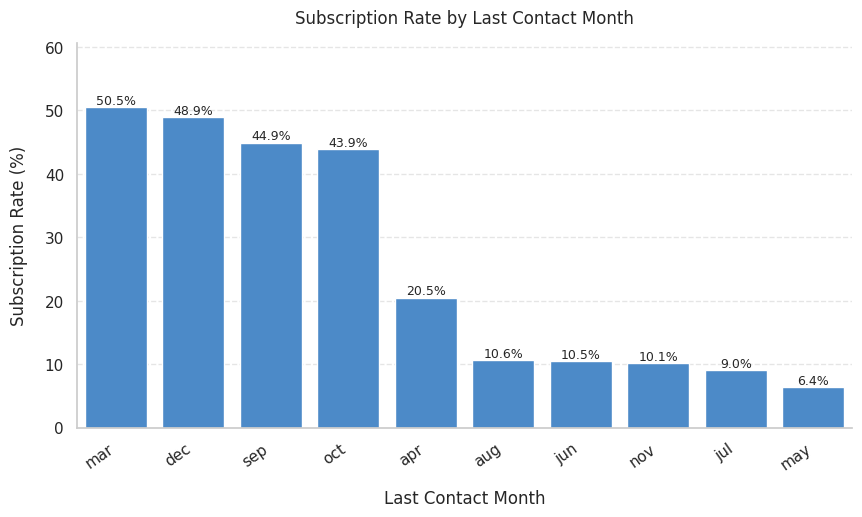

In [16]:
key_cats = ['job', 'marital', 'education', 'poutcome', 'contact', 'month']

for col in key_cats:
    fig, ax = plt.subplots(figsize=(10, 5))

    rate = (
        marketing.groupby(col)[TARGET]
        .apply(lambda x: (x == 'yes').mean() * 100)
        .sort_values(ascending=False)
        .reset_index()
    )
    rate.columns = [col, 'Subscription Rate (%)']

    sns.barplot(data=rate, x=col, y='Subscription Rate (%)',
                color=COLOUR_NO, ax=ax)

    if marketing[col].nunique() > 4:
        plt.xticks(rotation=35, ha='right')

    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', label_type='edge', fontsize=9)

    plt.title(f'Subscription Rate by {cat_feature_names.get(col, col)}', pad=14)
    plt.xlabel(cat_feature_names.get(col, col), labelpad=12)
    plt.ylabel('Subscription Rate (%)', labelpad=12)
    plt.ylim(0, rate['Subscription Rate (%)'].max() * 1.2)
    sns.despine(top=True, right=True)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.savefig(f'rate_{col.replace(".", "_")}.png', dpi=300)
    plt.show()
    print('\n')

## 3.13 Age by subscription outcome

Both classes centre on working age. Subscribers carry clear extra mass
past 60, matching the retired lead in 3.12. This tail is also why high
ages are not trimmed as outliers, it is where the customers are.

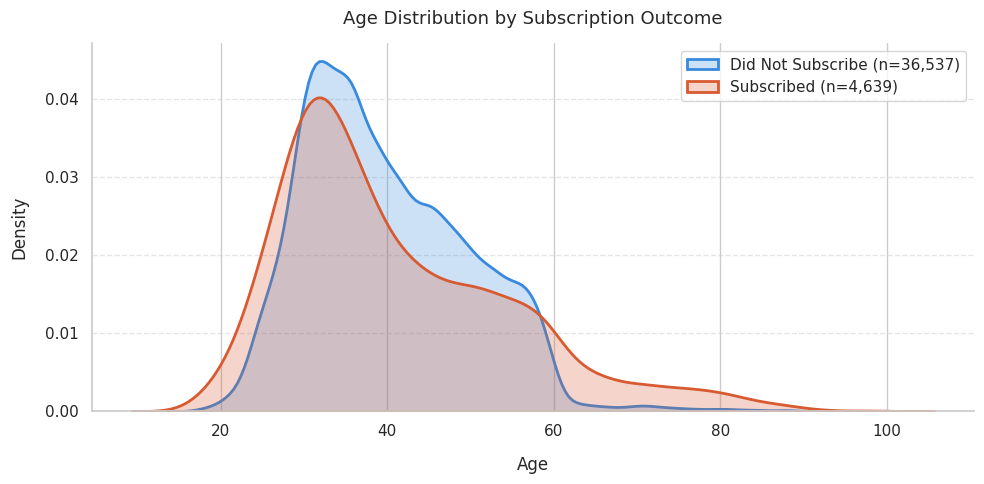

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))

for outcome, colour, label in [
    ('no',  COLOUR_NO,  f'Did Not Subscribe (n={counts["no"]:,})'),
    ('yes', COLOUR_YES, f'Subscribed (n={counts["yes"]:,})')
]:
    subset = marketing[marketing[TARGET] == outcome]['age']
    sns.kdeplot(subset, ax=ax, color=colour, label=label,
                linewidth=2, fill=True, alpha=0.25)

plt.title('Age Distribution by Subscription Outcome', pad=14, fontsize=13)
plt.xlabel('Age', labelpad=12)
plt.ylabel('Density', labelpad=12)
plt.legend(fontsize=11)
sns.despine(top=True, right=True)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('fig_age_by_subscription.png', dpi=300)
plt.show()

## 3.14 Correlation among the numerical features

emp.var.rate, euribor3m and nr.employed correlate above 0.9, all three
track the same economic cycle. pdays and previous correlate negatively for
the mechanical reason in 3.6. All features are kept, multicollinearity
distorts Logistic Regression coefficients but not predictions, and the
tree ensembles ignore it.

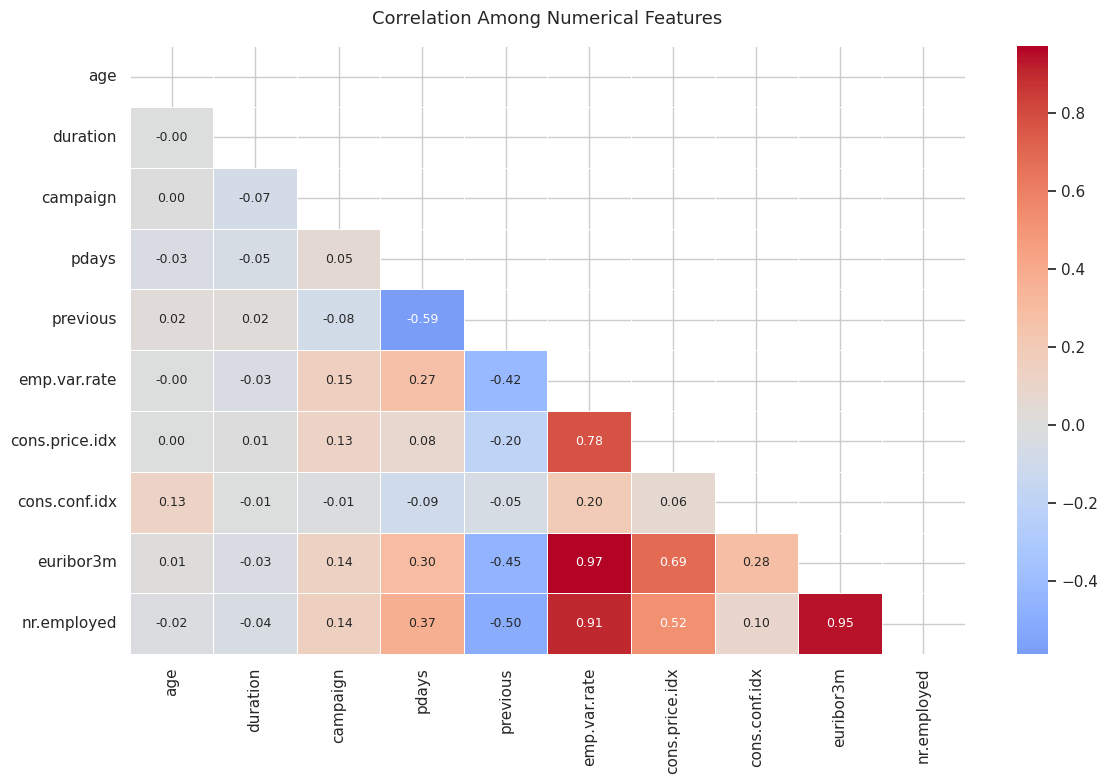

In [18]:
fig, ax = plt.subplots(figsize=(12, 8))

corr_matrix = marketing[num_features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            ax=ax, annot_kws={'size': 9})

plt.title('Correlation Among Numerical Features', pad=16, fontsize=13)
plt.tight_layout()
plt.savefig('fig_correlation_heatmap.png', dpi=300)
plt.show()


In [19]:

# euribor3m correlates 0.97 with emp.var.rate and 0.95 with nr.employed,

redundant = ['emp.var.rate', 'nr.employed']
marketing = marketing.drop(columns=redundant, errors='ignore')

print(f'Dropped: {redundant}')
print(f'Shape now: {marketing.shape}')
print('Numeric columns remaining:',
      marketing.select_dtypes(include='number').columns.tolist())

Dropped: ['emp.var.rate', 'nr.employed']
Shape now: (41176, 19)
Numeric columns remaining: ['age', 'duration', 'campaign', 'pdays', 'previous', 'cons.price.idx', 'cons.conf.idx', 'euribor3m']


## 3.15 Outlier detection

IQR is used instead of z scores because the features are skewed. Flagged
values are counted and kept. They are genuine customers, an 88 year old
retiree or a 40 minute call, exactly the clients the bank wants to find.
Robustness is handled by the scaler and the tree models, not by deletion.

In [20]:
outlier_results = {}

# Re-initialize num_features to reflect the current columns in the DataFrame
num_features = marketing.select_dtypes(include='number').columns.tolist()

for col in num_features:
    q1, q3 = marketing[col].quantile([0.25, 0.75])
    iqr    = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    count  = ((marketing[col] < lower) | (marketing[col] > upper)).sum()

    outlier_results[col] = {
        'Lower Bound'  : round(lower, 2),
        'Upper Bound'  : round(upper, 2),
        'Flagged Count': count,
        'Flagged (%)'  : round(count / len(marketing) * 100, 2)
    }

outlier_df = pd.DataFrame(outlier_results).T
outlier_df = outlier_df[outlier_df['Flagged Count'] > 0]

print(outlier_df.to_string())
print(f'\nTotal flagged values: {outlier_df["Flagged Count"].sum():,.0f}')
print('All records are retained.')

               Lower Bound  Upper Bound  Flagged Count  Flagged (%)
age                   9.50        69.50         468.00         1.14
duration           -223.50       644.50        2963.00         7.20
campaign             -2.00         6.00        2406.00         5.84
pdays               999.00       999.00        1515.00         3.68
previous              0.00         0.00        5625.00        13.66
cons.conf.idx       -52.15       -26.95         446.00         1.08

Total flagged values: 13,423
All records are retained.


## 3.16 Dataset state at the end of Part 1

Every number here is computed from the DataFrame, so this cell cannot
disagree with the data. It feeds Table 3.2 of the report, and Part 2
starts from this state.

In [21]:
state = {
    'Total records'                 : f'{len(marketing):,}',
    'Features (excluding target)'   : len(marketing.columns) - 1,
    'Numerical features'            : len(num_features),
    'Categorical features'          : len(cat_features),
    'NaN values'                    : marketing.isnull().sum().sum(),
    'Columns containing unknown'    : int((marketing == 'unknown').any().sum()),
    'Rows with pdays = 999'         : f'{(marketing["pdays"] == 999).sum():,}',
    'Class no'                      : f'{(marketing[TARGET] == "no").sum():,}'
                                      f'  ({(marketing[TARGET] == "no").mean()*100:.1f}%)',
    'Class yes'                     : f'{(marketing[TARGET] == "yes").sum():,}'
                                      f'  ({(marketing[TARGET] == "yes").mean()*100:.1f}%)'
}

print('Dataset state, end of Part 1')
print('=' * 50)
for k, v in state.items():
    print(f'  {k:30} : {v}')

Dataset state, end of Part 1
  Total records                  : 41,176
  Features (excluding target)    : 18
  Numerical features             : 8
  Categorical features           : 10
  NaN values                     : 0
  Columns containing unknown     : 6
  Rows with pdays = 999          : 39,661
  Class no                       : 36,537  (88.7%)
  Class yes                      : 4,639  (11.3%)



## Part 2: Data Preprocessing and Feature Engineering

This section covers Section 3.3 of the final report:

* Retaining the outliers flagged in Part 1, after trials showed removal
  harmed performance across every model
* Transforming the pdays column into two meaningful features
  (contact_date_known and days_since_contact)
* Engineering contact_intensity from campaign and previous
* Classifying features for the ColumnTransformer
* Splitting the data into stratified training and test sets
* Building the leakage-safe scikit-learn Pipeline: RobustScaler,
  OrdinalEncoder and OneHotEncoder, fitted on training data only
* Handling class imbalance through class weighting offered to the
  hyperparameter search, and through the decision threshold, with no
  resampling in the final pipeline
* Confirming the final dataset state before modelling

## 3.17 Modelling libraries

Everything the modelling work needs, loaded once. Decision Tree and SVM
are imported because the baseline trains all six models before two are
dropped on evidence in Chapter 4.



In [22]:
import time

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             average_precision_score,
                             confusion_matrix, ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore', message='X does not have valid feature names')

## 3.18 Transforming pdays

Section 3.6 established that 999 means the last contact date was not
recorded. The column becomes two features: a flag for whether the client
has prior contact history, and the number of days where it is known, with
999 replaced by -1 so no model reads it as a distance.

In [23]:
# 1 if pdays holds a real day count, 0 if it holds the 999 code
marketing['contact_date_known'] = (marketing['pdays'] != 999).astype(int)

# real day counts kept, the 999 code becomes -1
marketing['days_since_contact'] = marketing['pdays'].replace(999, -1)

# original column no longer needed
marketing.drop(columns='pdays', inplace=True)

print(f"Date known   : {marketing['contact_date_known'].sum():,}")
print(f"No date      : {(marketing['contact_date_known'] == 0).sum():,}")
print(f"Shape: {marketing.shape}")

Date known   : 1,515
No date      : 39,661
Shape: (41176, 20)


## 3.19 Engineered feature

contact_intensity sums the current campaign contacts and all previous
contacts, total pressure applied to a client across the relationship.
A long_call flag derived from duration was considered and rejected, it
duplicates information the tree models extract from duration directly,
and it would reintroduce call information into the without duration
experiments in Chapter 4.

In [24]:
marketing['contact_intensity'] = marketing['campaign'] + marketing['previous']

print(f"contact_intensity  min: {marketing['contact_intensity'].min()}  "
      f"max: {marketing['contact_intensity'].max()}  "
      f"mean: {marketing['contact_intensity'].mean():.2f}")
print(f"Shape: {marketing.shape}")

contact_intensity  min: 1  max: 56  mean: 2.74
Shape: (41176, 21)


## 3.20 Feature classification and target encoding

Each feature is assigned to one of three groups for the preprocessor. numerical, ordinary and norminal
Education is genuinely ordered, illiterate through university degree, so
it is encoded ordinally, with unknown mapped to -1 outside the scale.
Month is one hot encoded, its subscription rates are not monotonic across
the calendar, so treating it as an ordered number would mislead the
linear model. The assertion proves every feature is covered by exactly
one group.

In [25]:
X = marketing.drop(columns=TARGET)
y = (marketing[TARGET] == 'yes').astype(int)

# Numerical features currently in the DataFrame
num_cols = [
    'age', 'duration', 'campaign', 'previous',
    'cons.price.idx', 'cons.conf.idx',
    'euribor3m',
    'contact_date_known', 'days_since_contact',
    'contact_intensity' # Added missing feature
]

# Ordinal categorical — moving 'month' here as intended
ord_cols = ['education']
education_order = ['illiterate', 'basic.4y', 'basic.6y', 'basic.9y',
                   'high.school', 'professional.course', 'university.degree']

# Nominal categorical
nom_cols = ['job', 'marital', 'default', 'housing', 'loan',
            'contact', 'day_of_week', 'poutcome', 'month']

# This will now pass as the sets match
assert set(num_cols + ord_cols + nom_cols) == set(X.columns), 'A feature is unassigned'

print(f'Numerical ({len(num_cols)}), Ordinal ({len(ord_cols)}), ' f'Nominal ({len(nom_cols)})')
print(f'Target encoded 1=yes, 0=no: {y.value_counts().to_dict()}')

Numerical (10), Ordinal (1), Nominal (9)
Target encoded 1=yes, 0=no: {0: 36537, 1: 4639}


## 3.21 Train test split

A single stratified 80/20 split.

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f'Training: {len(X_train):,} rows, {y_train.mean()*100:.1f}% positive')
print(f'Test:     {len(X_test):,} rows, {y_test.mean()*100:.1f}% positive')

Training: 32,940 rows, 11.3% positive
Test:     8,236 rows, 11.3% positive


## 3.22 Preprocessing pipeline

One ColumnTransformer, fitted on training data only and applied unchanged
to the test set. RobustScaler uses the median and IQR, so the retained
outliers from Section 3.15 cannot distort the scaling. The pipeline has
two steps, preprocessing and model, the model slot is filled per
algorithm in Chapter 4.

In [27]:
preprocessor = ColumnTransformer([
    ('num', RobustScaler(), num_cols),
    ('ord', OrdinalEncoder(categories=[education_order],
                           handle_unknown='use_encoded_value',
                           unknown_value=-1), ord_cols),
    ('nom', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
     nom_cols)
])

pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', LogisticRegression())   # placeholder, replaced per model
])

print(pipeline)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', RobustScaler(),
                                                  ['age', 'duration',
                                                   'campaign', 'previous',
                                                   'cons.price.idx',
                                                   'cons.conf.idx', 'euribor3m',
                                                   'contact_date_known',
                                                   'days_since_contact',
                                                   'contact_intensity']),
                                                 ('ord',
                                                  OrdinalEncoder(categories=[['illiterate',
                                                                              'basic.4y',
                                                                              'basic.6y',
                                                          

## 4.1 Baseline, six models on defaults

All four candidates train on identical library defaults through the same
pipeline, so any later tuning gains are attributable to the search, not
to setup differences. duration is included at this stage, its removal is
a controlled experiment in Section 4.5. This produces Table 4.1, and the
CSV export preserves the exact numbers.

In [28]:
# Define a dictionary of candidate models with fixed seeds for reproducibility
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
    'Random Forest'      : RandomForestClassifier(random_state=42, n_jobs=-1),
    'XGBoost'            : XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1),
    'LightGBM'           : LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1)
}

# Initialize lists and dictionaries to store results and fitted objects
baseline_rows = []
fitted        = {}
probas        = {}

# Iterate through each model name and estimator
for name, model in models.items():
    # Combine the preprocessor with the estimator into a single pipeline
    pipe = Pipeline([('prep', preprocessor), ('model', model)])

    # Track training duration for efficiency analysis
    start = time.time()
    pipe.fit(X_train, y_train)
    elapsed = round(time.time() - start, 2)

    # Generate class predictions (0/1) and probability scores for the positive class
    pred  = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]

    # Calculate a comprehensive set of metrics to evaluate performance
    baseline_rows.append({
        'Model'         : name,
        'Accuracy'      : accuracy_score(y_test, pred),
        'Precision'     : precision_score(y_test, pred),
        'Recall'        : recall_score(y_test, pred),
        'F1-Score'      : f1_score(y_test, pred),
        'ROC-AUC'       : roc_auc_score(y_test, proba),
        'PR-AUC'        : average_precision_score(y_test, proba),
        'Train Time (s)': elapsed
    })

    # Store fitted pipelines and probabilities for later visualization
    fitted[name] = pipe
    probas[name] = proba
    print(f'{name:<20} trained in {elapsed}s')

# Summarize results in a DataFrame and export to CSV
baseline_df = pd.DataFrame(baseline_rows).set_index('Model').round(4)
print()
print(baseline_df.to_string())
baseline_df.to_csv('baseline_results.csv')

Logistic Regression  trained in 0.86s
Random Forest        trained in 5.39s
XGBoost              trained in 0.82s
LightGBM             trained in 0.61s

                     Accuracy  Precision  Recall  F1-Score  ROC-AUC  PR-AUC  Train Time (s)
Model                                                                                      
Logistic Regression      0.91       0.66    0.43      0.52     0.94    0.60            0.86
Random Forest            0.92       0.67    0.49      0.57     0.94    0.65            5.39
XGBoost                  0.91       0.63    0.57      0.60     0.95    0.64            0.82
LightGBM                 0.92       0.66    0.59      0.62     0.95    0.67            0.61


## 4.2 Baseline ROC curves

One curve per model against the random classifier diagonal. This is
Figure 4.1.

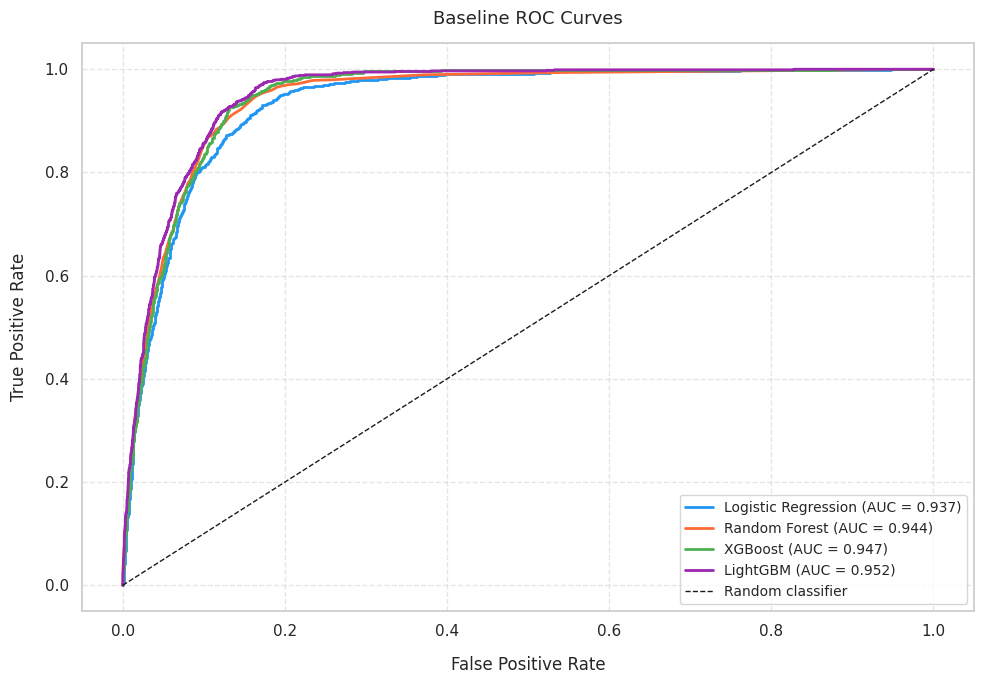

In [29]:
fig, ax = plt.subplots(figsize=(10, 7))
colours = ['#2196F3', '#FF6B35', '#4CAF50', '#9C27B0', '#795548', '#607D8B']

for (name, proba), colour in zip(probas.items(), colours):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, color=colour, linewidth=2,
            label=f'{name} (AUC = {auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')

plt.title('Baseline ROC Curves', pad=14, fontsize=13)
plt.xlabel('False Positive Rate', labelpad=12)
plt.ylabel('True Positive Rate', labelpad=12)
plt.legend(loc='lower right', fontsize=10)
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('fig_4_1_baseline_roc.png', dpi=300)
plt.show()

## 4.3 Baseline F1 comparison

F1 balances precision and recall on the minority class, which accuracy
cannot do at an 11.3% positive rate. This is Figure 4.2.

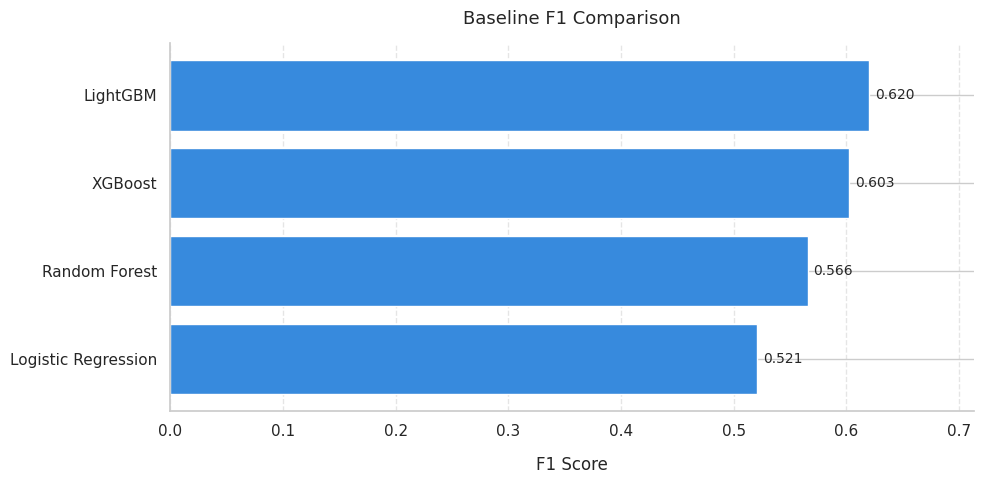

In [30]:
f1_sorted = baseline_df['F1-Score'].sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(f1_sorted.index, f1_sorted.values, color=COLOUR_NO)

for bar in bars:
    ax.text(bar.get_width() + 0.005,
            bar.get_y() + bar.get_height() / 2,
            f'{bar.get_width():.3f}', va='center', fontsize=10)

plt.title('Baseline F1 Comparison', pad=14, fontsize=13)
plt.xlabel('F1 Score', labelpad=12)
plt.xlim(0, f1_sorted.max() * 1.15)
sns.despine(top=True, right=True)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('fig_4_2_baseline_f1.png', dpi=300)
plt.show()

## 4.5 Hyperparameter grids

One grid per model. Class imbalance handling enters here as a tunable
choice, class_weight for the linear model and the forest,
scale_pos_weight for the boosters, so the search decides per model
whether rebalancing the loss helps. The ratio value is the negative to
positive ratio of the training data.

In [31]:
from scipy.stats import loguniform

ratio = round((y_train == 0).sum() / (y_train == 1).sum(), 2)
print(f'Negative to positive ratio: {ratio}')

param_grids = {
    'Logistic Regression': {
        'model__C'           : loguniform(1e-3, 1e2),
        'model__solver'      : ['lbfgs', 'liblinear'],
        'model__class_weight': [None, 'balanced']
    },
    'Random Forest': {
        'model__n_estimators'     : [200, 300, 500],
        'model__max_depth'        : [None, 10, 20, 30],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf' : [1, 2, 4],
        'model__max_features'     : ['sqrt', 'log2'],
        'model__class_weight'     : [None, 'balanced']
    },
    'XGBoost': {
        'model__n_estimators'    : [200, 400, 600],
        'model__max_depth'       : [3, 5, 7],
        'model__learning_rate'   : [0.01, 0.05, 0.1],
        'model__subsample'       : [0.7, 0.9, 1.0],
        'model__colsample_bytree': [0.7, 0.9, 1.0],
        'model__min_child_weight': [1, 5],
        'model__scale_pos_weight': [1, ratio]
    },
    'LightGBM': {
        'model__n_estimators'     : [200, 400, 600],
        'model__num_leaves'       : [31, 63, 127],
        'model__learning_rate'    : [0.01, 0.05, 0.1],
        'model__subsample'        : [0.7, 0.9, 1.0],
        'model__colsample_bytree' : [0.7, 0.9, 1.0],
        'model__min_child_samples': [20, 50, 100],
        'model__scale_pos_weight' : [1, ratio]
    }
}

Negative to positive ratio: 7.88


## 4.6 Tuning with and without duration

  Duration of a call is not known untill after the call is made

In [32]:
from sklearn.compose import make_column_selector

# A quick helper to rebuild the preprocessor whenever the list of numeric columns changes
def build_preprocessor(num_list):
    return ColumnTransformer([
        ('num', RobustScaler(), num_list),
        ('ord', OrdinalEncoder(categories=[education_order],
                               handle_unknown='use_encoded_value',
                               unknown_value=-1), ord_cols),
        ('nom', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
         nom_cols)
    ]).set_output(transform='pandas')

# These are the four models that made the cut for the final tuning phase
tuning_models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
    'Random Forest'      : RandomForestClassifier(random_state=42, n_jobs=-1),
    'XGBoost'            : XGBClassifier(random_state=42,
                                         eval_metric='logloss', n_jobs=-1),
    'LightGBM'           : LGBMClassifier(random_state=42,
                                          n_jobs=-1, verbose=-1)
}

# Will run everything twice: once with the 'leakage' (duration) and once for a realistic production scenario
feature_sets = {
    'with_duration'   : (X_train, X_test, num_cols),
    'without_duration': (X_train.drop(columns='duration'),
                         X_test.drop(columns='duration'),
                         [c for c in num_cols if c != 'duration'])
}

# Use 5 folds and keep the target ratio consistent across every slice
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

tuned_tables    = {}
best_estimators = {}
best_params     = {}

# The main engine: iterate through feature sets, then through each model
for fs_name, (X_tr, X_te, num_list) in feature_sets.items():
    print(f'\n=== Feature set: {fs_name} ===')
    prep = build_preprocessor(num_list)
    rows = []

    for name, model in tuning_models.items():
        # Create the full pipeline and start the randomized search
        pipe = Pipeline([('prep', prep), ('model', model)])

        search = RandomizedSearchCV(
            pipe, param_grids[name], n_iter=15,
            scoring='average_precision', cv=skf,
            random_state=42, n_jobs=-1
        )
        start = time.time()
        search.fit(X_tr, y_train)
        elapsed = round(time.time() - start, 1)

        # Grab the best version found and test it on the holdout data
        est   = search.best_estimator_
        pred  = est.predict(X_te)
        proba = est.predict_proba(X_te)[:, 1]

        # Log all the metrics so I can see if tuning actually improved the baseline
        rows.append({
            'Model'    : name,
            'Precision': precision_score(y_test, pred),
            'Recall'   : recall_score(y_test, pred),
            'F1-Score' : f1_score(y_test, pred),
            'ROC-AUC'  : roc_auc_score(y_test, proba),
            'PR-AUC'   : average_precision_score(y_test, proba),
            'Tune Time (s)': elapsed
        })

        # Save the actual models and params so I have to run this 1-hour cell again
        best_estimators[(fs_name, name)] = est
        best_params[(fs_name, name)]     = search.best_params_
        print(f'{name:<20} PR-AUC {rows[-1]["PR-AUC"]:.4f}  '
              f'F1 {rows[-1]["F1-Score"]:.4f}  {elapsed}s')

    tuned_tables[fs_name] = pd.DataFrame(rows).set_index('Model').round(4)

print('\nTuned, with duration (Table 4.2):')
print(tuned_tables['with_duration'].to_string())
print('\nTuned, without duration (Table 4.3, headline):')
print(tuned_tables['without_duration'].to_string())



=== Feature set: with_duration ===
Logistic Regression  PR-AUC 0.6024  F1 0.5183  31.8s


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Random Forest        PR-AUC 0.6691  F1 0.5509  525.9s
XGBoost              PR-AUC 0.6718  F1 0.6085  184.0s
LightGBM             PR-AUC 0.6712  F1 0.6203  439.8s

=== Feature set: without_duration ===
Logistic Regression  PR-AUC 0.4525  F1 0.3079  31.1s


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Random Forest        PR-AUC 0.4790  F1 0.3105  525.6s
XGBoost              PR-AUC 0.4820  F1 0.4850  163.0s
LightGBM             PR-AUC 0.4851  F1 0.3514  391.1s

Tuned, with duration (Table 4.2):
                     Precision  Recall  F1-Score  ROC-AUC  PR-AUC  Tune Time (s)
Model                                                                           
Logistic Regression       0.66    0.43      0.52     0.94    0.60          31.80
Random Forest             0.70    0.45      0.55     0.95    0.67         525.90
XGBoost                   0.45    0.95      0.61     0.95    0.67         184.00
LightGBM                  0.66    0.59      0.62     0.95    0.67         439.80

Tuned, without duration (Table 4.3, headline):
                     Precision  Recall  F1-Score  ROC-AUC  PR-AUC  Tune Time (s)
Model                                                                           
Logistic Regression       0.66    0.20      0.31     0.80    0.45          31.10
Random Forest             

## 4.7 The cost of duration

The direct answer to the leakage question, how much apparent performance
came from a variable unknowable before the call. This is Table 4.4, and
it sits beside the comparison to Moro et al. (2014), who report ROC AUC
near 0.80 in the same realistic setting.

In [33]:
impact = pd.DataFrame({
    'ROC-AUC with'   : tuned_tables['with_duration']['ROC-AUC'],
    'ROC-AUC without': tuned_tables['without_duration']['ROC-AUC'],
    'PR-AUC with'    : tuned_tables['with_duration']['PR-AUC'],
    'PR-AUC without' : tuned_tables['without_duration']['PR-AUC'],
})
impact['ROC-AUC drop'] = (impact['ROC-AUC with'] - impact['ROC-AUC without']).round(4)
impact['PR-AUC drop']  = (impact['PR-AUC with'] - impact['PR-AUC without']).round(4)
print(tuned_tables.keys())
print(impact.to_string())
impact.to_csv('duration_impact.csv')

dict_keys(['with_duration', 'without_duration'])
                     ROC-AUC with  ROC-AUC without  PR-AUC with  PR-AUC without  ROC-AUC drop  PR-AUC drop
Model                                                                                                     
Logistic Regression          0.94             0.80         0.60            0.45          0.14         0.15
Random Forest                0.95             0.81         0.67            0.48          0.14         0.19
XGBoost                      0.95             0.81         0.67            0.48          0.14         0.19
LightGBM                     0.95             0.82         0.67            0.49          0.14         0.19


## 4.8 Precision recall curves without duration

The four tuned realistic models against the no skill line, which for PR
curves is the positive prevalence, not a diagonal. This is Figure 4.3.

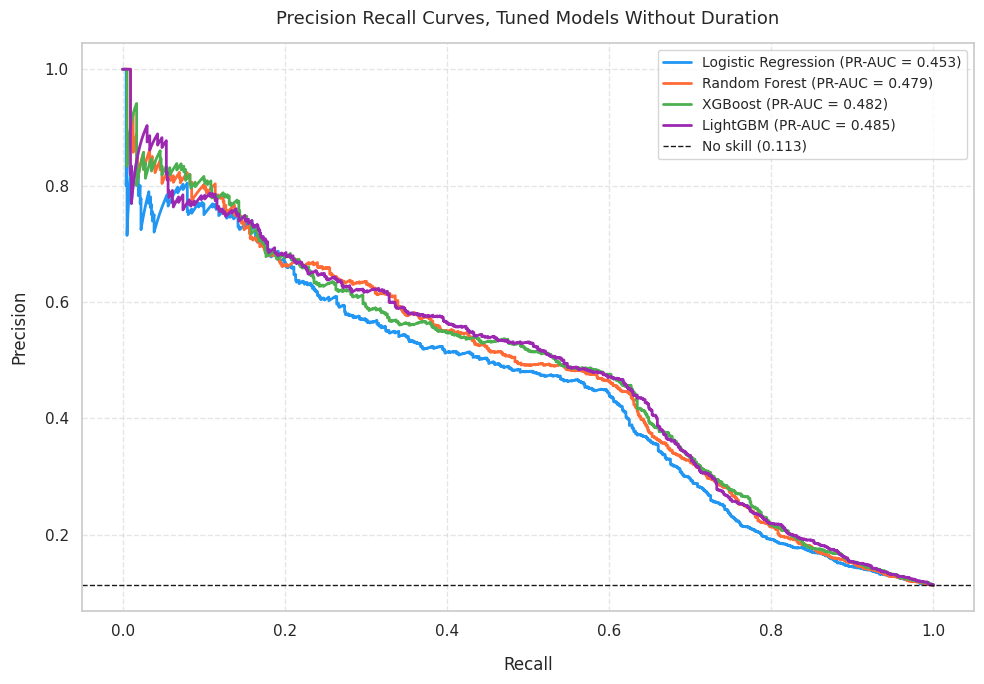

In [34]:
from sklearn.metrics import precision_recall_curve

fig, ax = plt.subplots(figsize=(10, 7))
colours = ['#2196F3', '#FF6B35', '#4CAF50', '#9C27B0']

# I'm using the specific test set where I dropped 'duration' to keep things realistic for production.
X_te_nd = feature_sets['without_duration'][1]

# loop through each model to calculate its specific PR curve.
for (name, _), colour in zip(tuning_models.items(), colours):
    est   = best_estimators[('without_duration', name)]
    proba = est.predict_proba(X_te_nd)[:, 1]

    # I calculate the precision and recall coordinates for every potential threshold.
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    ax.plot(rec, prec, color=colour, linewidth=2,
            label=f'{name} (PR-AUC = {ap:.3f})')
ax.axhline(y_test.mean(), color='k', linestyle='--', linewidth=1,
           label=f'No skill ({y_test.mean():.3f})')
plt.title('Precision Recall Curves, Tuned Models Without Duration',
          pad=14, fontsize=13)
plt.xlabel('Recall', labelpad=12)
plt.ylabel('Precision', labelpad=12)
plt.legend(loc='upper right', fontsize=10)
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('fig_4_3_pr_curves.png', dpi=300)
plt.show()


## 4.9 Picking the Best Decision Cutoff

The default 0.50 cutoff is often too strict for imbalanced datasets where subscribers are rare. To fix this, I identify the best-performing 'realistic' model based on its PR-AUC score.Then use cross-validation on the training data to hunt for the specific threshold that maximizes the F1-score.


In [35]:
from sklearn.model_selection import cross_val_predict

# First, I'll check my 'realistic' results and grab the champion model—the one with the highest PR-AUC.
best_name = tuned_tables['without_duration']['PR-AUC'].idxmax()
best_pipe = best_estimators[('without_duration', best_name)]
X_tr_nd   = feature_sets['without_duration'][0]

print(f'Best realistic model: {best_name}')
print(f'Parameters: {best_params[("without_duration", best_name)]}')

# Use cross-validation here to get 'out-of-fold' scores on the training set.
oof_proba = cross_val_predict(best_pipe, X_tr_nd, y_train, cv=skf,
                              method='predict_proba', n_jobs=-1)[:, 1]
prec, rec, thresholds = precision_recall_curve(y_train, oof_proba)
f1_curve = 2 * prec * rec / (prec + rec + 1e-12) #lookind for best F1 score
best_thr = thresholds[np.argmax(f1_curve[:-1])]
print(f'\nSelected threshold: {best_thr:.4f}')

# With my optimal threshold locked in, I can finally apply it to the holdout test set.
proba_test = best_pipe.predict_proba(X_te_nd)[:, 1]

# Let's compare the standard 0.50 cutoff against my custom-tuned one to see the real-world boost.
for label, thr in [('Default 0.50', 0.5), (f'Tuned {best_thr:.2f}', best_thr)]:
    pred = (proba_test >= thr).astype(int)
    print(f'\n{label}:')
    print(f'  Precision {precision_score(y_test, pred):.4f}  '
          f'Recall {recall_score(y_test, pred):.4f}  '
          f'F1 {f1_score(y_test, pred):.4f}  '
          )

Best realistic model: LightGBM
Parameters: {'model__subsample': 0.7, 'model__scale_pos_weight': 1, 'model__num_leaves': 31, 'model__n_estimators': 600, 'model__min_child_samples': 20, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.9}

Selected threshold: 0.2163

Default 0.50:
  Precision 0.6455  Recall 0.2414  F1 0.3514  

Tuned 0.22:
  Precision 0.4778  Recall 0.5927  F1 0.5291  


## 4.10 Confidence intervals for the final model

1,000 bootstrap resamples of the test set give 95% intervals for F1 and
PR AUC.

In [36]:
# How much does F1 wobble if the test set had been slightly different?
# We can't collect a new test set, so we simulate 1,000 of them by resampling
# the one we have (drawing clients at random, with repeats allowed), then look
# at the spread of scores. The middle 95% of that spread is the confidence interva
rng        = np.random.default_rng(42)
y_arr      = y_test.to_numpy()
pred_final = (proba_test >= best_thr).astype(int)

f1_samples, ap_samples = [], []
for _ in range(1000):

    # pick 8,236 test clients at random, with replacement -> one simulated test set
    idx = rng.integers(0, len(y_arr), len(y_arr))
    if y_arr[idx].sum() == 0:
        continue
    f1_samples.append(f1_score(y_arr[idx], pred_final[idx]))
    ap_samples.append(average_precision_score(y_arr[idx], proba_test[idx]))

# chop off the extreme 2.5% at each end -> the central 95% range
f1_lo, f1_hi = np.percentile(f1_samples, [2.5, 97.5])
ap_lo, ap_hi = np.percentile(ap_samples, [2.5, 97.5])

print(f'Final model: {best_name}, without duration, threshold {best_thr:.2f}')
print(f'F1    : {f1_score(y_arr, pred_final):.4f}  '
      f'(95% CI {f1_lo:.4f} to {f1_hi:.4f})')
print(f'PR-AUC: {average_precision_score(y_arr, proba_test):.4f}  '
      f'(95% CI {ap_lo:.4f} to {ap_hi:.4f})')

Final model: LightGBM, without duration, threshold 0.22
F1    : 0.5291  (95% CI 0.5028 to 0.5552)
PR-AUC: 0.4851  (95% CI 0.4492 to 0.5211)


## 4.11 Saved model and prediction demonstration

 The
pipeline and threshold are saved, reloaded from disk, for testing

In [37]:
import joblib

joblib.dump(best_pipe, 'final_model.joblib')
joblib.dump(best_thr, 'final_threshold.joblib')

loaded_model = joblib.load('final_model.joblib')
loaded_thr   = joblib.load('final_threshold.joblib')

customer = X_te_nd.iloc[[0]].copy()
customer['age']      = 37
customer['job']      = 'high.school'
customer['poutcome'] = 'nonexistent'
customer['duration'] = 226
customer['campaign'] = 1

proba = loaded_model.predict_proba(customer)[0, 1]
decision = 'SUBSCRIBE' if proba >= loaded_thr else 'NO SUBSCRIPTION'

print(customer.to_string(index=False))
print(f'\nSubscription probability: {proba:.3f}')
print(f'Decision at threshold {loaded_thr:.2f}: {decision}')

 age         job marital   education default housing loan   contact month day_of_week  campaign  previous    poutcome  cons.price.idx  cons.conf.idx  euribor3m  contact_date_known  days_since_contact  contact_intensity  duration
  37 high.school married high.school unknown      no   no telephone   jun         wed         1         0 nonexistent           94.47         -41.80       4.86                   0                  -1                 14       226

Subscription probability: 0.045
Decision at threshold 0.22: NO SUBSCRIPTION


## 4.12 What drives the final model

Permutation importance on the held out test set, measured as the drop in
PR AUC when each feature is shuffled. Unlike built in importances this
works on the original features through the pipeline and reflects the
metric the study optimises. This is Figure 4.4.

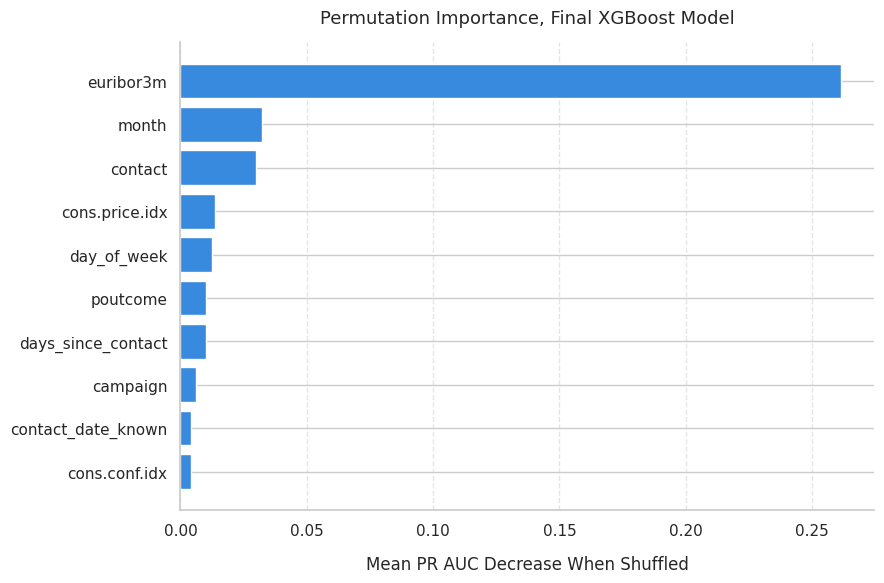

In [38]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    best_pipe, X_te_nd, y_test, scoring='average_precision',
    n_repeats=10, random_state=42, n_jobs=-1
)

imp = (pd.Series(perm.importances_mean, index=X_te_nd.columns)
       .sort_values().tail(10))

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(imp.index, imp.values, color=COLOUR_NO)
plt.title('Permutation Importance, Final XGBoost Model', pad=14, fontsize=13)
plt.xlabel('Mean PR AUC Decrease When Shuffled', labelpad=12)
sns.despine(top=True, right=True)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('fig_4_4_permutation_importance.png', dpi=300)
plt.show()

## 4.13 The threshold decision

Precision and recall as the cutoff moves, computed on the out of fold
training predictions from 4.9. The vertical line marks the selected
0.20, where F1 peaks. This is Figure 4.5.

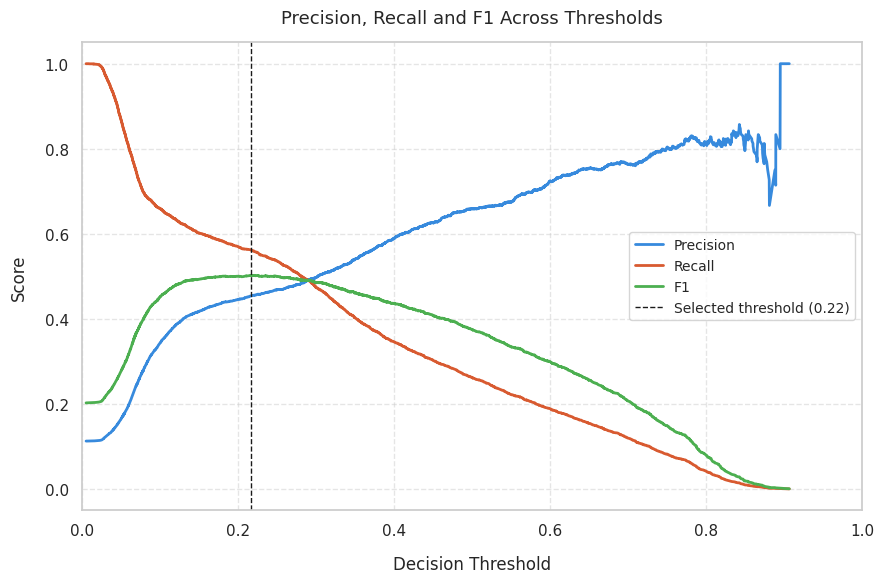

In [39]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(thresholds, prec[:-1], color=COLOUR_NO,  linewidth=2, label='Precision')
ax.plot(thresholds, rec[:-1],  color=COLOUR_YES, linewidth=2, label='Recall')
ax.plot(thresholds, f1_curve[:-1], color='#4CAF50', linewidth=2, label='F1')
ax.axvline(best_thr, color='k', linestyle='--', linewidth=1,
           label=f'Selected threshold ({best_thr:.2f})')

plt.title('Precision, Recall and F1 Across Thresholds', pad=14, fontsize=13)
plt.xlabel('Decision Threshold', labelpad=12)
plt.ylabel('Score', labelpad=12)
plt.xlim(0, 1)
plt.legend(fontsize=10)
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('fig_4_5_threshold_tradeoff.png', dpi=300)
plt.show()

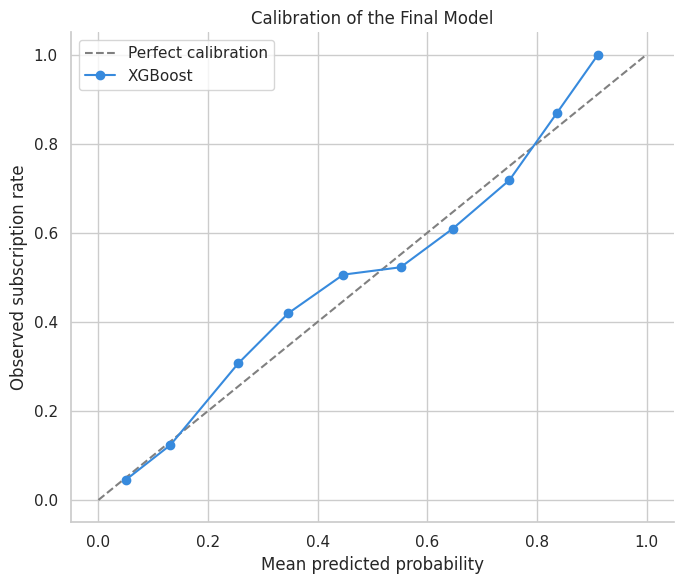

In [40]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, proba_test, n_bins=10)
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0, 1], [0, 1], '--', color='grey', label='Perfect calibration')
ax.plot(prob_pred, prob_true, 'o-', color=COLOUR_NO, label='XGBoost')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Observed subscription rate')
ax.set_title('Calibration of the Final Model')
ax.legend(); sns.despine(top=True, right=True)
plt.tight_layout(); plt.savefig('fig_4_6_calibration.png', dpi=300); plt.show()

## 4.14 Confusion matrix at the final threshold

The final model's test set decisions as counts of customers. This is
Figure 4.6.

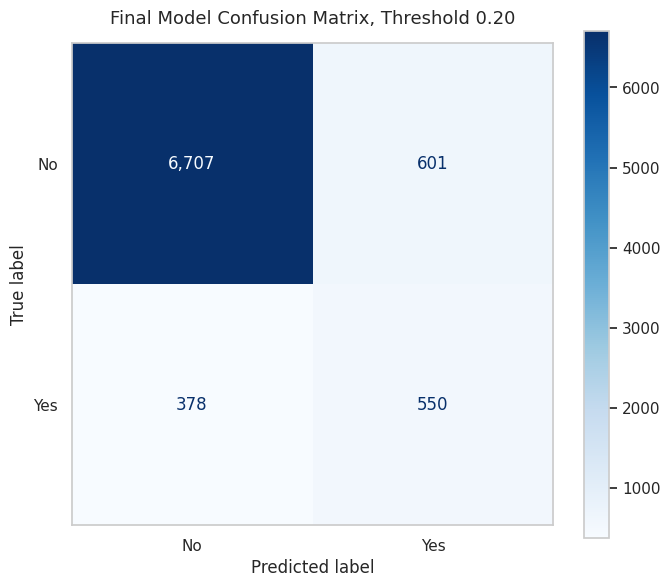

In [41]:
cm = confusion_matrix(y_test, (proba_test >= best_thr).astype(int))

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm, display_labels=['No', 'Yes']).plot(
    ax=ax, cmap='Blues', values_format=','
)
plt.title('Final Model Confusion Matrix, Threshold 0.20', pad=14, fontsize=13)
plt.tight_layout()
ax.grid(False)
plt.savefig('fig_4_6_confusion_matrix.png', dpi=300)
plt.show()